In [44]:
# Standard libraries
import warnings
from typing import Tuple, List, Union, Any

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.axes

# Model persistence
import joblib

# Preprocessing & pipelines
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Model inspection & interpretability
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.inspection import partial_dependence, permutation_importance
from lime.lime_tabular import LimeTabularExplainer
!pip install --quiet alibi
from alibi.explainers import AnchorTabular
import shap
from model import WhiteBox

# Warnings
from sklearn.exceptions import InconsistentVersionWarning
import warnings
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
warnings.filterwarnings("ignore", message=".*CuPy may not function correctly.*")



from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- Imbalanced-learn ---
# pipeline with samplers
from imblearn.pipeline import Pipeline as ImbPipeline   
# base class for SMOTE/ADASYN/etc.
from imblearn.base import BaseSampler                   
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Initialize SHAP visualizations
shap.initjs()


# **It's Jaundice's World, and St. James Hospital is Just Living in It.**

### Authors:  Mariel Concepcion, Lorenzo De Villa, Bingbong Manglicmot, Caitlin Sebastian, JF Viray
### Learning Team: 7
---

# **1. Executive Summary**

Data Monitors developed a machine learning model for St. James Hospital’s OB-GYN facility to classify newborns as either at risk or healthy. Thirteen weeks after deployment, a newborn was misclassified as healthy and died, with similar cases later uncovered being misclassified as healthy. The incident eroded trust in the system and triggered an independent audit. We take  this case with two goals: to understand why the model failed in classifying the at-risk babies and to design a more reliable classification process.

Our explainability analysis revealed that the model relied too heavily on jaundice levels when predicting a baby’s health risk. Using global explainability tools such as SHAP values, permutation importance, and model coefficients, we found that jaundice consistently ranked far above every other feature. Feature interaction analysis using Friedman’s H-statistic further supported this finding, showing relatively weak dependencies between jaundice and the other variables, with only about 42% with oxygen saturation and 34% with heart rate. 

Local explainability methods allowed us to go further by identifying the concrete rules the model applies. Using anchors, we found that the most common rule is that if a baby’s jaundice level is below 4.30 mg/dL, the model will always predict the baby to be healthy no matter the value of the other features. LIME further illustrated that two otherwise similar babies could be classified differently based solely on their jaundice levels. Together, these local analyses show that while jaundice is a valid indicator of health, the model’s overreliance on it creates blind spots that are dangerous in practice.

To correct this, we developed a baseline Random Forest model that spreads importance more evenly across features. The new model achieved an F1 score of 99.1% for at-risk babies and an overall F1 score of 99.8%. Moreover, we propose a new process for determining a baby’s health with a human in the loop. Using TreeExplainer, we make it clear to medical staff why the model classified a baby in a particular way. If a baby is at risk, we provide a counterfactual explanation to show what feature changes would result in a healthy classification. These results demonstrate that careful model design, combined with explainability, can improve both performance and reliability.


(The project environment is set up with Python version 3.12.8.)

---

# **2. Introduction** 
Data Monitors deployed a machine learning model at St. James Hospital’s OB-GYN facility to classify newborns as healthy or at risk, aiming to reduce the monitoring burden on staff. It was so successful that the staff “don’t need to monitor the babies that actively anymore.” However, in its thirtieth week, the system misclassified an at-risk newborn as healthy, resulting in the infant’s death. A review revealed other misclassifications, undermining trust in the algorithm. This raises the challenge of understanding why the current system failed (Figure 1a) and developing a reliable replacement to support medical decision-making, as illustrated in the proposed business process (Figure 1b).

![Old (a) and New (b) Business Process](figures/01_business_process.png)
**Figure 1**. Old (a) and New (b) Business Process


In line with this, we focus on three main objectives: 
1. To understand why the system failed by using global and local explainability methods;
2. To develop a stronger and more reliable model meant to support medical decision-making; and
3. To propose a new process for developing similar ML modelling efforts and strategies for a more connected and interoperable hospital data system 

Based on these objectives, we ask the following key questions:

1. Feature Analysis
    * Which features primarily influenced the model’s predictions for healthy versus at-risk babies? 
    * Given the features identified as important by the model, is there a medical rationale for their use, and did the model rely too heavily on any specific features?
2. Model Improvement
    * Which metrics are most appropriate for the objective of the OB-GYN facility?
    * Should strategies such as class balancing or feature engineering be applied? 
    * Does the redesigned model correctly classify the previously misclassified babies, and how does it perform overall on both healthy and at-risk populations?

---

# **3. Methodology**

![Methodology](figures/02_methodology.png)
**Figure 2.** Overview of the Methodology

### **3.1 Determine Important Features using Global Model-Agnositic Methods**
Global explainability methods were applied to assess feature importance across the entire dataset. Specifically, we used SHAP values, permutation feature importance, and Friedman’s H-statistic to identify which variables the model relied on most heavily when making predictions.

### **3.2 Cite Specific Examples using Local Model-Agnostic Methods**
Local explainability tools were employed to examine individual predictions. Anchors, ICE plots, and LIME were used to provide concrete examples of how the model made decisions for specific babies, highlighting potential blind spots and feature overreliance.

### **3.3 Improve the Model of Data Monitors**
To create a more reliable replacement, we tested multiple modeling approaches while experimenting with different strategies to handle class imbalance between the at-risk and healthy babies. We also added counterfactual explanations, allowing medical staff to see how changes in specific features could alter a baby’s predicted health risk.


---


# **4. Results and Discussion**

## 4.1 Determine Important Features using Global Model-Agnositic Methods

We used global explainability methods to identify the features most influential in the model's predictions. SHAP values were then used to aggregate individual feature contributions and provide a visual summary of the model’s overall behavior as seen in Figure 3. This analysis revealed that jaundice level, followed by heart rate, were the most critical risk factors. High jaundice values strongly pushed predictions toward 'At Risk,' while low oxygen saturation and low birth weight also contributed to higher risk. 


In [2]:
# Set many of the variables to be used
historical_df = pd.read_csv('data/historical.csv')
misclassified_df = pd.read_csv('data/corrected_false_negatives.csv')

# the model by data monitors as old_model
old_model = joblib.load("data/model.joblib")

In [3]:
# Get processor and classifier from pipeline
processor = old_model["preprocess"]
clf = old_model["clf"]

# Get just the features
feature_names = historical_df.columns[:-1]
X_hist = historical_df[feature_names]

# Get preprocessed X and its feature names
X_preprocessed = processor.transform(X_hist)
preprocessed_feature_names = list(processor.get_feature_names_out())

# Get X and only its features and y where its label encoded
X = historical_df[processor.feature_names_in_]
y = historical_df[historical_df.columns[-1]].map({"Healthy": 0, "At Risk": 1})
y_class = historical_df[historical_df.columns[-1]]
#y = historical_df[historical_df.columns[-1]]

# Get the misclassified babies and their indices
X_hist['orig_index'] = X_hist.index

X_misclassified = X_hist.merge(
    misclassified_df,
    on=['baby_id', 'name', 'gender', 'date'],
    how='inner'
)

# Get the misclassified babies' indices and drop the index column
misclassified_indices = X_misclassified['orig_index'].tolist()
X_misclassified.drop(columns=['orig_index'], inplace=True)
X_hist.drop(columns=['orig_index'], inplace=True)

  0%|          | 0/100 [00:00<?, ?it/s]

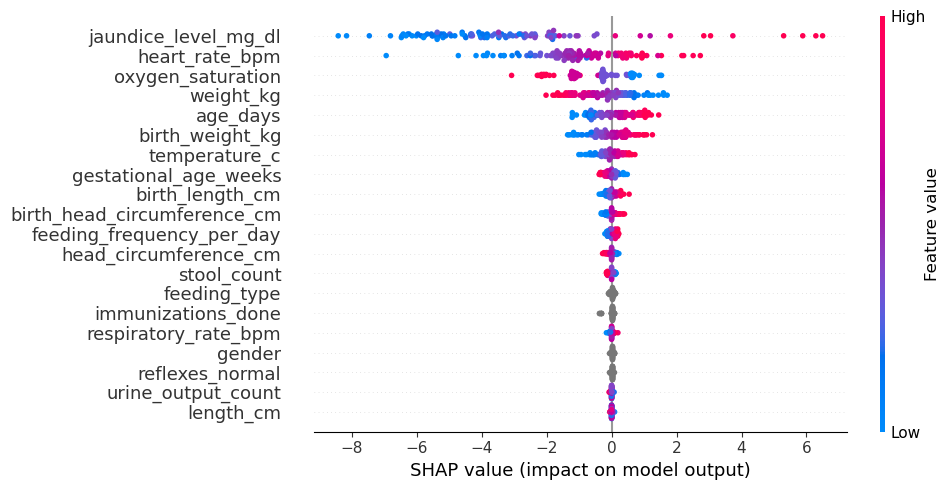

Figure 3. SHAP Summary: Key Drivers of At-Risk Predictions in Newborns


In [4]:
# Use the same X from permutation importance (raw features)
X_for_shap = X.copy()

# Wrap model function to keep DataFrame structure
model_fn = lambda x: old_model.predict_proba(
    pd.DataFrame(x, columns=X_for_shap.columns)
)

# Create KernelExplainer
shap_explainer = shap.KernelExplainer(
    model=model_fn,
    data=shap.sample(X_for_shap, 100, random_state=42),
    feature_names=X_for_shap.columns,
    link="logit"  # since we're predicting probabilities
)

# Compute SHAP values (on a sample for speed)
X_sample = shap.sample(X_for_shap, 100, random_state=42)
shap_values = shap_explainer.shap_values(X_sample)

# Select the class index you want to explain (1 = "At Risk")
class_idx = 1

# Summary plot (same format as your old code)
shap.summary_plot(
    shap_values[:, :, class_idx],
    X_sample,
    plot_size=(10, 5)
)

fig_count = 3
print(f'\033[1mFigure {fig_count}\033[0m. '
      'SHAP Summary: Key Drivers of At-Risk Predictions in Newborns'
)

fig_count += 1 

This result makes sense when looking at the histograms of Figure 4 where babies at risk are more likely to have a high level of jaundice. This is also medically meaningful because elevated bilirubin levels, which cause jaundice, can indicate liver immaturity or hemolytic disorders in newborns, both of which increase the risk of complications if not managed promptly (Hall et al., 2025). 

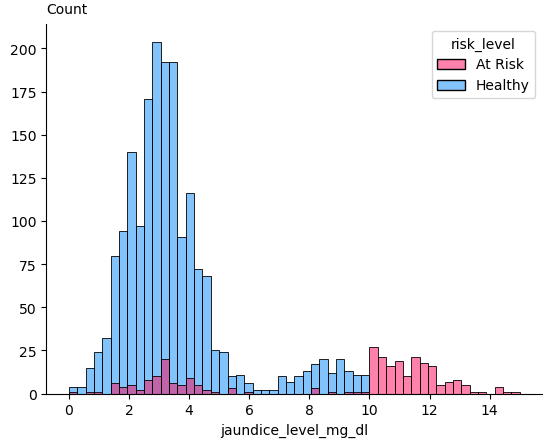

Figure 4. Distribution of Jaundice Levels by Risk Level


In [5]:
sns.histplot(
    data=historical_df,
    x='jaundice_level_mg_dl',
    hue='risk_level',
    palette={'Healthy': '#0888fa', 'At Risk': '#fd0556'},  # specify colors

);

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().yaxis.set_label_coords(0, 1.02)
plt.ylabel('Count', rotation=0, ha='left')
plt.show()
print(f'\033[1mFigure {fig_count}\033[0m. Distribution of Jaundice Levels by Risk Level')
fig_count += 1 


Although it makes sense to have jaundice as an important feature because of the clear dividing line it has in Figure 4, further analysis indicated that the model was overreliant on this specific variable. We used permutation importance to quantify how much each feature affects the model's performance. Given the medical context, recall is a crucial metric because it directly measures the ability of the model to avoid false negatives. Because the babies’ lives are at risk, we prioritized in making sure that a baby is not accidentally classified as healthy even though they are actually at risk. As seen in Figure 5, the level of jaundice caused an approximate 50% drop in recall when shuffled, whereas other features had much smaller effects. 

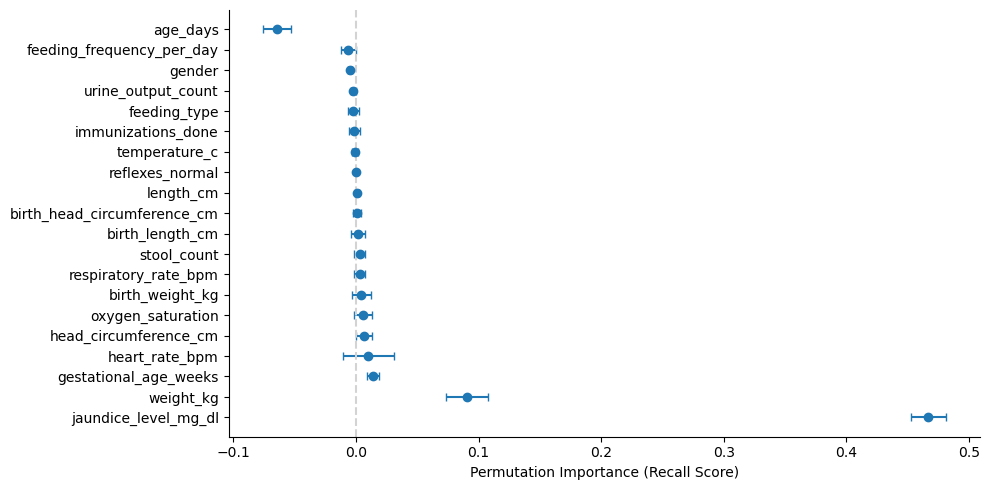

Figure 5. Permutation Importance


In [6]:
# Compute permutation importance on the pipeline
perm_imp = permutation_importance(
    old_model,
    X,
    y,
    scoring="recall",
    random_state=42,
    n_repeats=5
)

# Use raw column names (not preprocessed ones) for interpretability
FEATURE_NAMES = np.array(X.columns)

# Sort by importance
idx_order = np.argsort(-perm_imp.importances_mean)
ordered_means = perm_imp.importances_mean[idx_order]
ordered_stds = perm_imp.importances_std[idx_order]
ordered_labels = FEATURE_NAMES[idx_order]

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(
    x=ordered_means,
    y=ordered_labels,
    xerr=ordered_stds,
    fmt="o",
    capsize=3
)
plt.xlabel("Permutation Importance (Recall Score)")
plt.axvline(0, linestyle="--", c="lightgray")
#plt.title("Permutation Importance (Using Model Features Only)")
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Permutation Importance'
)

fig_count += 1 


Given what we found from SHAP and permutation importance, feature interaction analysis using Friedman’s H-statistic further confirms that jaundice mostly acts independently. The H-statistic showed weak interactions between jaundice and oxygen saturation (42%) and between jaundice and heart rate (34%), which aligns with SHAP’s indication that jaundice is the dominant contributor to predictions and permutation importance’s demonstration that shuffling jaundice drastically reduces recall. This reinforces that the model focused heavily on jaundice because it is both highly influential and largely independent of the other features.

In [7]:
def h_statistic(
    model: Union[BaseEstimator, "Pipeline"], 
    X: pd.DataFrame, 
    feat1: str, 
    feat2: str, 
    grid_resolution: int = 20
) -> float:
    """
    Compute Friedman’s H-statistic between two features (feat1, feat2).
    
    Parameters:
    -----------
    model : trained sklearn model or pipeline with predict_proba
    X : pandas DataFrame
        Input features (not yet transformed by preprocessors)
    feat1, feat2 : str
        Names of the two features to compute interaction for
    grid_resolution : int
        How many grid points for PDPs (higher = more accurate, slower)
        
    Returns:
    --------
    float : H-statistic value (0 = no interaction, 1 = pure interaction)
    """
    
    features = [feat1, feat2]
    
    # Joint 2D PDP
    pd_joint = partial_dependence(model, X, features=features,
                                  grid_resolution=grid_resolution,
                                  kind="average")
    pd_joint_values = pd_joint["average"][0]
    
    # Individual PDPs
    pd_feat1 = partial_dependence(model, X, features=[feat1],
                                  grid_resolution=grid_resolution,
                                  kind="average")["average"][0]
    pd_feat2 = partial_dependence(model, X, features=[feat2],
                                  grid_resolution=grid_resolution,
                                  kind="average")["average"][0]
    
    # Reshape for broadcasting
    pd_feat1 = pd_feat1.reshape(-1, 1)
    pd_feat2 = pd_feat2.reshape(1, -1)
    
    # Numerator: variance of interaction effect
    interaction_effect = pd_joint_values - pd_feat1 - pd_feat2
    numerator = np.var(interaction_effect)
    
    # Denominator: variance of joint PDP
    denominator = np.var(pd_joint_values)
    
    h_val = np.sqrt(numerator / denominator) if denominator > 0 else 0.0
    return h_val

def bootstrap_h(
    model: BaseEstimator,
    X: pd.DataFrame,
    feat1: str,
    feat2: str,
    n_boot: int = 50
) -> Tuple[float, np.ndarray]:
    """
    Estimate the H-statistic with bootstrapping to get a confidence interval.

    Parameters
    ----------
    model : sklearn estimator
        Trained model used for computing H-statistic.
    X : pd.DataFrame
        Input features (original, untransformed).
    feat1 : str
        Name of the first feature.
    feat2 : str
        Name of the second feature.
    n_boot : int, default=50
        Number of bootstrap samples.

    Returns
    -------
    Tuple[float, np.ndarray]
        - Mean H-statistic across bootstrap samples.
        - 2.5th and 97.5th percentile confidence interval as a numpy array.
    """
    h_vals: List[float] = []
    n_samples: int = len(X)

    for _ in range(n_boot):
        sample_idx: np.ndarray = np.random.choice(n_samples, n_samples, replace=True)
        X_sample: pd.DataFrame = X.iloc[sample_idx]
        h_vals.append(h_statistic(model, X_sample, feat1, feat2))

    h_vals_array: np.ndarray = np.array(h_vals)
    mean_h: float = h_vals_array.mean()
    ci: np.ndarray = np.percentile(h_vals_array, [2.5, 97.5])

    return mean_h, ci

In [8]:
# Prepare a pipeline for the h_statistic

# Drop unused columns
dropped_columns = ['name', 'date']
X_encoded = X_hist.copy()
X_encoded = X_encoded.drop(columns=dropped_columns)

# Fill missing 'apgar_score' per baby_id, then drop baby_id
X_encoded['apgar_score'] = (
    X_encoded
    .groupby('baby_id')['apgar_score']
    .transform(lambda x: x.fillna(x.median() if x.notna().any() else 0))
)

# Drop baby_id after using it for filling
X_encoded = X_encoded.drop(columns=['baby_id'], errors='ignore')

# Identify categorical features
preprocessor = old_model['preprocess']
categorical_features = preprocessor.transformers_[1][2]  
categorical_indices = [X_encoded.columns.get_loc(col) for col in categorical_features]

# Encode categorical columns as integers
categorical_names = {}
for idx, feature in zip(categorical_indices, categorical_features):
    X_encoded[feature] = X_encoded[feature].astype("category").cat.codes
    categorical_names[idx] = list(X_encoded[feature].astype("category").cat.categories)

# Ensure numeric columns are float
numeric_features = [col for col in X_encoded.columns if col not in categorical_features]
X_encoded[numeric_features] = X_encoded[numeric_features].astype(float)

# ColumnTransformer
recreated_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), preprocessor.transformers_[0][2]),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), preprocessor.transformers_[1][2])
    ],
    remainder='drop'   # drops baby_id, name, date (in case it hasn't been dropped beforehand)
)

recreated_preprocessor.fit(X_encoded)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['gestational_age_weeks', 'birth_weight_kg',
                                  'birth_length_cm',
                                  'birth_head_circumference_cm', 'age_days',
                                  'weight_kg', 'length_cm',
                                  'head_circumference_cm', 'temperature_c',
                                  'heart_rate_bpm', 'respiratory_rate_bpm',
                                  'oxygen_saturation',
                                  'feeding_frequency_per_day',
                                  'urine_output_count', 'stool_count',
                                  'jaundice_level_mg_dl']),
                                ('cat',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore'),
                                 ['gender', 'feeding_type',
                                  'immunizations_done', 'reflexes_normal'])])

In [9]:
# Have a pipeline for the h_statistic
model_pipeline = Pipeline(steps=[
    ('preprocess', recreated_preprocessor),
    ('clf', old_model['clf'])
])

mean_h_jaundice_oxygen, ci_jaundice_oxygen = bootstrap_h(model_pipeline, X_encoded, 'jaundice_level_mg_dl', 'oxygen_saturation', n_boot=50)
print("H mean between jaundice and oxygen_saturation:", mean_h_jaundice_oxygen, "\n95% CI:", ci_jaundice_oxygen)
print("")

mean_h_jaundice_heart, ci_jaundice_heart = bootstrap_h(model_pipeline, X_encoded, 'jaundice_level_mg_dl', 'heart_rate_bpm', n_boot=50)
print("H mean between jaundice and heart_rate_bpm:", mean_h_jaundice_heart, "\n95% CI:", ci_jaundice_heart)
print("")

mean_h_oxygen_heart, ci_oxygen_heart = bootstrap_h(model_pipeline, X_encoded, 'oxygen_saturation', 'heart_rate_bpm', n_boot=50)
print("H mean between oxygen saturation and heart_rate_bpm:", mean_h_oxygen_heart, "\n95% CI:", ci_oxygen_heart)

H mean between jaundice and oxygen_saturation: 0.5237294898108928 
95% CI: [0.5073611  0.54153261]

H mean between jaundice and heart_rate_bpm: 0.43222596570423555 
95% CI: [0.40712089 0.45692118]

H mean between oxygen saturation and heart_rate_bpm: 0.4039739974833061 
95% CI: [0.37740002 0.43395739]


## 4.2 Cite Specific Examples using Local Model-Agnostic Methods

For local explainability, we now aim to concretely identify the rules Data Monitor’s model uses when it overrelies on jaundice and to provide concrete examples of the patterns revealed through global explainability. First, we applied anchors to find a simple and interpretable rule. As shown in the table below, the most common rule is that if a baby’s jaundice level is below 4.30 mg/dL, the model predicts the baby to be healthy. The precision of 100% means that every baby in the dataset with a jaundice level under this threshold was classified as "Healthy." This highlights the overreliance on the jaundice level since for the babies who were misclassified, it was most often case that their jaundice level was low. Thus, the model followed its highly confident rule, saw the low jaundice level, and ignored other high-risk indicators, such as high heart rate or low oxygen, resulting in a confident but incorrect prediction of "Healthy."

In [10]:
# Wrap model prediction for Anchor
def predictor(X):
    baby_df = pd.DataFrame(X, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict(baby_transformed)

explainer = AnchorTabular(
    predictor=predictor,
    feature_names=X_encoded.columns.tolist(),
    categorical_names=categorical_names
)

# Fit on training data
explainer.fit(
    X_encoded.values.astype(np.float64),
    disc_perc=[25, 50, 75]
)

# create a dict
anchors = {}
# Pick an instance to explain
for idx in misclassified_indices:
    anchors[idx] = {}
    instance = X_encoded.iloc[idx].values.reshape(1, -1).astype(np.float64)

    # Generate explanation
    explanation = explainer.explain(instance)

    anchors[idx]['Anchor rule'] = explanation.anchor
    anchors[idx]['Precision'] = explanation.precision
    anchors[idx]['Coverage'] = explanation.coverage

In [11]:
# Convert to DataFrame, making anchors tuples or strings
df_anchors = pd.DataFrame.from_dict(anchors, orient='index')
# convert list to string
df_anchors['Anchor rule'] = df_anchors['Anchor rule'].apply(lambda x: ' & '.join(x))  

# Group by anchor rule and compute median + count
summary = df_anchors.groupby('Anchor rule').agg(
    Precision=('Precision', 'median'),
    Coverage=('Coverage', 'median'),
    Count=('Anchor rule', 'count')  # how often each anchor appears
).sort_values(['Count', 'Precision'], ascending=[False, False])

display(summary.style.format({
    'Precision': "{:.2%}",
    'Coverage': "{:.2%}"
}))


print(f"\033[1mTable 1\033[0m. Summary of Anchor Explanations for Key Features")

,Precision,Coverage,Count
Anchor rule,,,
jaundice_level_mg_dl <= 4.30,100.00%,75.67%,14
jaundice_level_mg_dl <= 3.25,100.00%,49.66%,4
oxygen_saturation > 98.00,97.69%,14.57%,2
jaundice_level_mg_dl <= 2.50,100.00%,27.15%,1
weight_kg > 3.67 & age_days > 8.00,99.78%,41.56%,1
weight_kg > 3.67 & age_days > 15.50,99.52%,32.25%,1
oxygen_saturation > 98.00 & heart_rate_bpm <= 133.00,98.04%,4.40%,1
heart_rate_bpm <= 140.00 & weight_kg > 3.67,97.31%,27.68%,1
heart_rate_bpm <= 133.00 & oxygen_saturation > 97.00,97.03%,13.82%,1


Table 1. Summary of Anchor Explanations for Key Features


The ICE plots in Figure 7 show individual predicted risks for babies across different feature values. Unlike PDPs, which show average effects, ICE plots let us focus on individual babies, especially the misclassified ones. The red dots mark each baby’s actual feature values, anchoring predictions to real observations. Misclassified babies often appear in ranges where the model is very confident, such as jaundice levels below 4.30 mg/dL. This reflects the anchors analysis, where we saw that the model applies a highly confident rule based on low jaundice. We also observe clustering of data for jaundice since low values consistently lead the model to predict healthy, while predictions for the heart rate and oxygen saturation are much more varied.

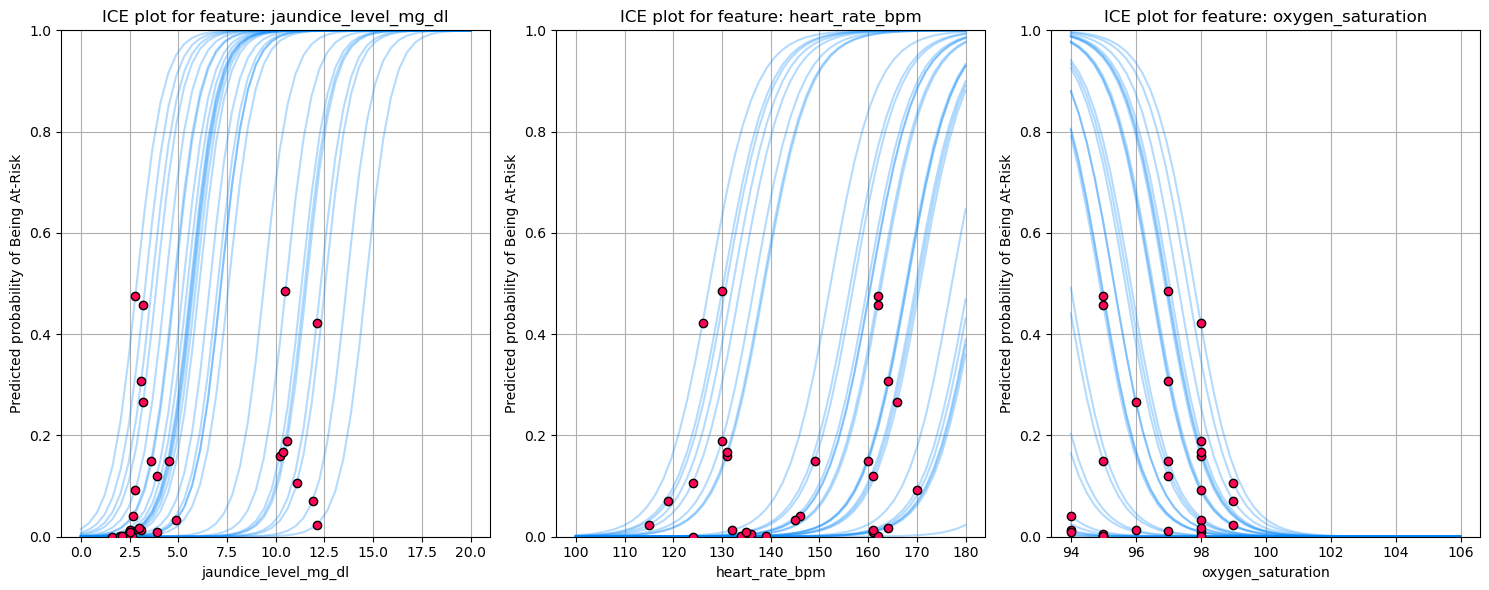

In [12]:
def plot_ice_multiple_with_dots(
    instances: pd.DataFrame,
    feature: str,
    value_range: np.ndarray | List[float] | List[int],
    ax: matplotlib.axes.Axes,
    preprocessor: BaseEstimator | TransformerMixin,  
    model: BaseEstimator, 
    ylim: Tuple[float, float] = (0, 1),
    alpha: float = 0.3,
) -> None:
    """
    Plot ICE curves for a feature across multiple instances with a dot at each instance's original value.
    """
    for i in range(len(instances)):
        instance = instances.iloc[[i]]
        preds: List[float] = []
        for val in value_range:
            temp: pd.DataFrame = instance.copy()
            temp[feature] = val
            temp_transformed: np.ndarray = preprocessor.transform(temp)
            pred: float = model.predict_proba(temp_transformed)[0, 1]
            preds.append(pred)
        
        # Plot the ICE curve
        ax.plot(value_range, preds, marker=None, alpha=alpha, color='#0888fa')
        
        # Plot a dot at the original feature value
        orig_value = instance[feature].values[0]
        orig_pred = model.predict_proba(preprocessor.transform(instance))[0, 1]
        ax.scatter(orig_value, orig_pred, color='#fd0556', edgecolor="black", zorder=5)
    
    ax.set_xlabel(feature)
    ax.set_ylabel("Predicted probability of Being At-Risk")
    ax.set_title(f"ICE plot for feature: {feature}")
    ax.set_ylim(*ylim)
    ax.grid(True)

# Example usage for misclassified babies
misclassified_babies = X_encoded.iloc[misclassified_indices]  # replace misclassified_mask with your boolean mask
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# The actual min and max
# features_info = [
#     ("jaundice_level_mg_dl", np.linspace(0, 15, 50)),
#     ("heart_rate_bpm", np.linspace(100, 173, 50)),
#     ("oxygen_saturation", np.linspace(94, 101, 50))
# ]

# What if scenario
features_info = [
    ("jaundice_level_mg_dl", np.linspace(0, 20, 50)),
    ("heart_rate_bpm", np.linspace(100, 180, 50)),
    ("oxygen_saturation", np.linspace(94, 106, 50))
]

for ax, (feature, value_range) in zip(axs, features_info):
    plot_ice_multiple_with_dots(
        misclassified_babies, feature, value_range, ax,
        recreated_preprocessor, old_model['clf']
    )

plt.tight_layout()
plt.show()


Finally, to show a concrete example of how the model overrelied on jaundice, we used LIME to compare two mostly similar babies. We manually reviewed the misclassified cases and identified the most similar babies, Nicole and Tara. Both had comparable heart rates, oxygen saturation levels, and weight with only minor differences in age in days and body temperature. The primary distinction between them was their jaundice level, with Nicole exhibiting a low jaundice level and Tara a high one. The model assigned a higher probability of being at risk to Tara (29%) and a lower probability to Nicole (9%), indicating that jaundice was the main factor influencing the model’s confidence in these predictions.

In [13]:
# Create the LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_encoded.values,
    feature_names=X_encoded.columns.tolist(),
    class_names=['Healthy', 'At Risk'],
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    kernel_width=3
)

# Create an anonymous function where given a sample, it predicts using the rf model
def predict_fn(baby):
    baby_df = pd.DataFrame(baby, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict_proba(baby_transformed)

for i in [1341, 57]:
    misclassified_baby = historical_df.loc[i]
    print(f"{misclassified_baby['name']} of index {i} "
          f"was misclassified as healthy on {misclassified_baby['date']}")

    exp = explainer.explain_instance(
        X_encoded.iloc[i].values,   # 1D numpy array
        predict_fn,
        num_features=5
    )

    exp.show_in_notebook(show_all=True)

print(f'\033[1mFigure {fig_count}\033[0m. '
      'LIME Explanation of Model Predictions for Two Similar Babies'
)

fig_count += 1 

Tara of index 1341 was misclassified as healthy on 2025-03-15


Nicole of index 57 was misclassified as healthy on 2025-08-24


Figure 6. LIME Explanation of Model Predictions for Two Similar Babies


From both the perspectives of the global and local view, we see that jaundice is indeed clearly a strong predictor. However, the model relied on it too heavily, creating blind spots that were risky in practice.

## 4.3 Improve the model of Data Monitors

In [14]:
lr_df = pd.read_csv('LR_results.csv')
lr_df

,method,f1_pos,recall_pos,precision_pos,f1_weighted
0,Baseline LR,0.660377,0.625000,0.700000,0.912210
1,CC-SMOTE LR,0.619355,0.857143,0.484848,0.874600
2,RUS LR,0.601399,0.767857,0.494253,0.875978
3,SMOTE LR,0.595745,0.750000,0.494118,0.875427
4,SMOTE-TOMEK LR,0.595745,0.750000,0.494118,0.875427
5,Class Weight LR,0.589041,0.767857,0.477778,0.870278
6,ROS LR,0.589041,0.767857,0.477778,0.870278
7,SMOTE-ENN LR,0.569620,0.803571,0.441176,0.856204


In [15]:
rf_results = pd.read_csv('RF_results.csv')
rf_results

,method,f1_pos,recall_pos,precision_pos,f1_weighted
0,Baseline RF,0.990991,0.982143,1.000000,0.997610
1,ROS RF,0.990991,0.982143,1.000000,0.997610
2,SMOTE RF,0.973451,0.982143,0.964912,0.992884
3,SMOTE-TOMEK RF,0.973451,0.982143,0.964912,0.992884
4,Class Weight RF,0.972477,0.946429,1.000000,0.992774
5,RUS RF,0.916667,0.982143,0.859375,0.976852
6,SMOTE-ENN RF,0.785714,0.982143,0.654762,0.934286
7,CC-SMOTE RF,0.268585,1.000000,0.155125,0.277577


As seen from the table above, we will use Baseline Random Forest as it has the highest values for each of the metrics compared to the other resampling methods.

### 4.3.1 Preprocessing the data 

In [43]:
df = pd.read_csv("data/historical.csv")

In [42]:
# --- Define columns ---
minmax_cols = ['age_days', 'feeding_frequency_per_day', 'urine_output_count', 'stool_count']
standardize_cols = [
    'gestational_age_weeks', 'weight_kg', 'length_cm', 'head_circumference_cm',
    'temperature_c', 'heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation',
    'jaundice_level_mg_dl'
]
categorical_cols = ['gender', 'feeding_type', 'immunizations_done', 'reflexes_normal']

# --- ColumnTransformer Preprocessor ---
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), minmax_cols),
        ('standard', StandardScaler(), standardize_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'
)

In [41]:
# --- Feature and Target separation ---
X = df.drop(columns=['risk_level']).copy()
y = df['risk_level'].copy()

# --- Encode target (risk_level) to numeric ---
# Example: 'Low' -> 0, 'High' -> 1
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# --- Train–Validation Split ---
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Pipeline using WhiteBox model ---
wb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', WhiteBox(random_state=1234))
])

# --- Train ---
wb_pipeline.fit(X_train, y_train)

# --- Predict ---
y_preds = wb_pipeline.predict(X_val)

# --- Evaluate ---
print("\nPerformance on the Validation Set:\n")
print(f"F1 Score: {f1_score(y_val, y_preds, average='weighted'):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_preds))
print("\nValidation Set Confusion Matrix:\n")
print(pd.DataFrame(confusion_matrix(y_val, y_preds)))


Performance on the Validation Set:

F1 Score: 0.9976

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        56
           1       1.00      1.00      1.00       364

    accuracy                           1.00       420
   macro avg       1.00      0.99      0.99       420
weighted avg       1.00      1.00      1.00       420


Validation Set Confusion Matrix:

    0    1
0  55    1
1   0  364


___

# **5. Conclusion and Recommendations** 

___

# **References**

Cheah, P. C. Y., Yang, Y., & Lee, B. G. (2023, September 5). Enhancing financial fraud detection 
through addressing class imbalance using Hybrid smote-gan techniques. MDPI. 
https://www.mdpi.com/2227-7072/11/3/110  

Federal Trade Commission. (2025, March 10). New FTC Data Show a Big Jump in Reported Losses to Fraud to $12.5 Billion in 2024. U.S. Federal Trade Commission. https://www.ftc.gov/news-events/news/press-releases/2025/03/new-ftc-data-show-big-jump-reported-losses-fraud-125-billion-2024

Vedešin, A. (2025). What Are Fraud Detection Rules: Types and Best Practices. Vespia. https://vespia.io/blog/fraud-detection-rules

Wainer, J. (2016). An empirical evaluation of imbalanced data strategies from a practitioner’s point of view (Technical Report 1606.00930). arXiv. Retrieved from https://arxiv.org/abs/1606.00930

Wang, Y. (2025, March 27). A data balancing and Ensemble Learning Approach for credit card 
fraud detection. arXiv.org. https://arxiv.org/abs/2503.21160 

---

# **Supplementary**
